# Label propagation

In many real problems, collecting data is cheap but **labeling** it is expensive (a human expert has to look at every sample). We often end up with a large dataset where only a handful of points are labeled. This is the setting of **semi-supervised learning**.

**Label propagation** (Zhu & Ghahramani, 2002) is a simple and elegant semi-supervised method. The idea:

1. Build a **graph** connecting points that are close to each other.
2. Let the known labels **flow along the edges** of the graph, step by step, until every point has received a label.

The underlying assumption (the *cluster assumption*) is that points that are connected by a path through dense regions of the data should have the same label.

In this notebook we will:
* build the similarity graph,
* implement label propagation from scratch with Numpy,
* visualize how the labels spread over the iterations,
* compute the solution in closed form,
* compare with the implementation of scikit-learn.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib import animation
from IPython.display import HTML
from sklearn.datasets import make_moons

## 1. The data: two moons with very few labels

We use the classical "two moons" dataset from scikit-learn. It has 2 classes shaped like interleaved half circles. A linear classifier cannot separate them, and with only a few labels even a non-linear classifier will struggle.

We know the true label of every point, but we **hide** most of them: only 3 points per class are kept as labeled. By convention, unlabeled points get the label `-1`.

In [2]:
X, y = make_moons(n_samples=200, noise=0.08, random_state=0)
n = len(X)       # number of points
n_classes = 2

# For each class, choose at random a few points that keep their label
n_labeled_per_class = 3
rng = np.random.default_rng(1)
labeled_idx = []
for c in range(n_classes):
    points_of_class_c = np.where(y == c)[0]   # indices of all the points of class c
    chosen = rng.choice(points_of_class_c, n_labeled_per_class, replace=False)
    labeled_idx.extend(chosen)
labeled_idx = np.array(labeled_idx)

# All the other points are unlabeled
unlabeled_idx = []
for i in range(n):
    if i not in labeled_idx:
        unlabeled_idx.append(i)
unlabeled_idx = np.array(unlabeled_idx)

# The labels seen by the algorithm: -1 means "unknown"
y_observed = np.full(n, -1)
for i in labeled_idx:
    y_observed[i] = y[i]

print("Number of points:", n, "- labeled:", len(labeled_idx), "- unlabeled:", len(unlabeled_idx))
print("Indices of the labeled points:", labeled_idx)
print("Their labels:", y[labeled_idx])

Number of points: 200 - labeled: 6 - unlabeled: 194
Indices of the labeled points: [106  98 152 161 184  26]
Their labels: [0 0 0 1 1 1]


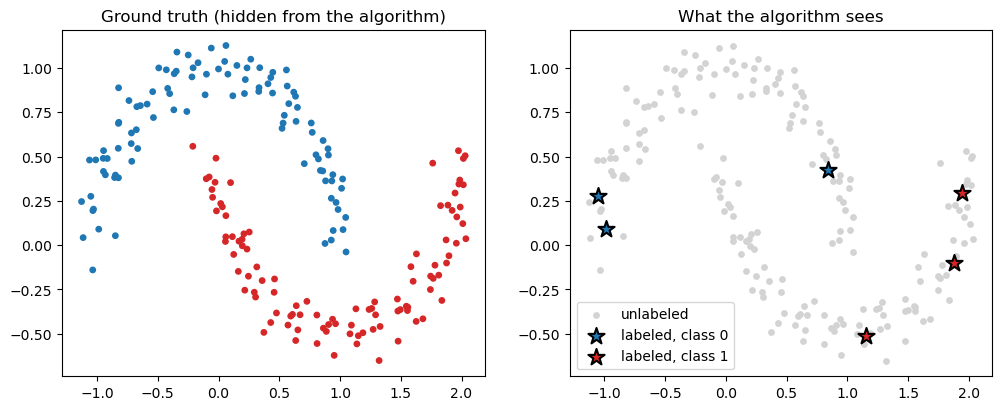

In [3]:
class_colors = ['tab:blue', 'tab:red']

def labels_to_colors(labels):
    # Convert a list of labels (0 or 1) into a list of colors
    colors = []
    for label in labels:
        colors.append(class_colors[label])
    return colors

def plot_labeled_points(ax):
    # Draw the labeled points as big stars with a black edge
    for c in range(n_classes):
        # Find the labeled points that belong to class c
        idx = []
        for i in labeled_idx:
            if y[i] == c:
                idx.append(i)
        ax.scatter(X[idx, 0], X[idx, 1], s=150, c=class_colors[c], edgecolors='k',
                   linewidths=1.5, marker='*', zorder=3, label=f'labeled, class {c}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: all the true labels
axes[0].scatter(X[:, 0], X[:, 1], c=labels_to_colors(y), s=15)
axes[0].set_title('Ground truth (hidden from the algorithm)')

# Right: only the few labeled points
axes[1].scatter(X[unlabeled_idx, 0], X[unlabeled_idx, 1], c='lightgrey', s=15, label='unlabeled')
plot_labeled_points(axes[1])
axes[1].set_title('What the algorithm sees')
axes[1].legend(loc='lower left')
plt.show()

## 2. Building the similarity graph

Each data point becomes a node of a graph. We connect each point to its $k$ nearest neighbors, and give the edge between $x_i$ and $x_j$ a weight that is large when the points are close (a Gaussian, or RBF, kernel):

$$ w_{ij} = \exp\left(-\frac{\|x_i - x_j\|^2}{2\sigma^2}\right) \quad \text{if } j \text{ is among the } k \text{ nearest neighbors of } i \text{ (or the reverse)}, \qquad w_{ij} = 0 \text{ otherwise.}$$

All the weights are stored in an $n \times n$ matrix $W$, the **adjacency matrix** of the graph. It is symmetric ($w_{ij} = w_{ji}$) and we set $w_{ii} = 0$ (no self-loops).

Two parameters control the graph:
* $k$: how many neighbors each point is connected to,
* $\sigma$: the length scale of the kernel.

In [4]:
def build_knn_graph(X, k=10, sigma=0.2):
    n = len(X)

    # Step 1: squared distance between every pair of points
    sq_dists = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            diff = X[i] - X[j]
            sq_dists[i, j] = np.sum(diff**2)

    # Step 2: find which points are connected.
    # connected[i, j] = True if j is one of the k nearest neighbors of i, or the reverse.
    connected = np.zeros((n, n), dtype=bool)
    for i in range(n):
        order = np.argsort(sq_dists[i])   # all the points, sorted from the closest to the farthest
        neighbors = order[1:k+1]          # skip order[0], which is the point i itself
        for j in neighbors:
            connected[i, j] = True
            connected[j, i] = True        # the graph is symmetric

    # Step 3: give a weight to each edge with the Gaussian kernel
    W = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if connected[i, j]:
                W[i, j] = np.exp(-sq_dists[i, j] / (2 * sigma**2))
    return W

k = 10
sigma = 0.2
W = build_knn_graph(X, k=k, sigma=sigma)
print("Shape of W:", W.shape)
print("Number of edges:", np.count_nonzero(W) // 2)   # each edge appears twice in W: (i, j) and (j, i)
print("Symmetric:", np.allclose(W, W.T))

Shape of W: (200, 200)
Number of edges: 1145
Symmetric: True


Let us draw the graph. The darker an edge, the larger its weight.

To draw many lines at once, we use a matplotlib `LineCollection`: we give it the list of all the segments, each segment being a pair of points `[start, end]`. This is much faster than calling `plt.plot` once per edge.

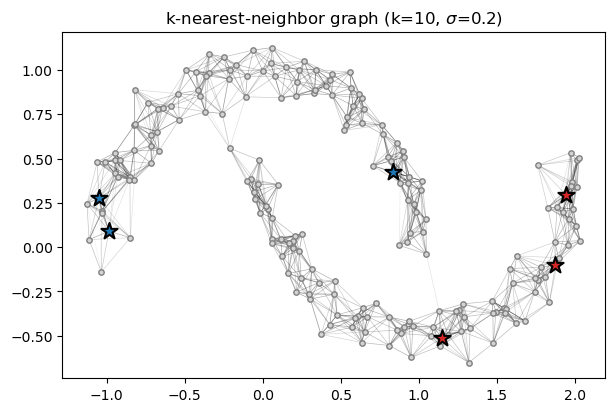

In [5]:
def plot_graph_edges(ax, W, alpha=0.4):
    segments = []      # list of the edges, each one given as [start point, end point]
    opacities = []     # transparency of each edge: proportional to its weight
    n = len(W)
    for i in range(n):
        for j in range(i + 1, n):    # j > i, so that each edge is drawn only once
            if W[i, j] > 0:
                segments.append([X[i], X[j]])
                opacities.append(alpha * W[i, j] / W.max())
    lines = LineCollection(segments, colors='k', linewidths=0.5, alpha=opacities)
    ax.add_collection(lines)

fig, ax = plt.subplots(figsize=(7, 4.5))
plot_graph_edges(ax, W)
ax.scatter(X[unlabeled_idx, 0], X[unlabeled_idx, 1], c='lightgrey', edgecolors='grey', s=15, zorder=2)
plot_labeled_points(ax)
ax.set_title(f'k-nearest-neighbor graph (k={k}, $\\sigma$={sigma})')
plt.show()

Notice that there are many edges inside each moon, and very few edges between the two moons. This is exactly what label propagation will exploit: the labels will travel easily inside a moon, but hardly cross over to the other one.

## 3. The label propagation algorithm

We store the label information in a matrix $F$ of size $n \times C$ ($C$ = number of classes). Row $i$ contains the "amount" of each class that point $i$ has received:
* for a labeled point, the row is the one-hot encoding of its label, e.g. $[1, 0]$ for class 0;
* for an unlabeled point, we start with $[0, 0]$: no information.

We define the **transition matrix** $T = D^{-1} W$, where $D$ is the diagonal matrix of the degrees $d_i = \sum_j w_{ij}$. Each row of $T$ sums to 1, and $T_{ij}$ can be seen as the probability to jump from node $i$ to node $j$.

The algorithm repeats two steps:
1. **Propagate**: $F \leftarrow T F$. Each point takes the weighted average of the labels of its neighbors.
2. **Clamp**: reset the rows of the labeled points to their true one-hot labels (we never forget what we know for sure).

At the end, each point gets the class with the largest value in its row: $\hat{y}_i = \arg\max_c F_{ic}$.

Intuitively, the labels act like sources of heat (or ink) that diffuse through the graph.

### The transition matrix

First we compute the degree $d_i = \sum_j w_{ij}$ of each node, then divide each row $i$ of $W$ by $d_i$. Let us check that the rows of $T$ sum to 1.

In [6]:
def transition_matrix(W):
    n = len(W)
    degrees = np.sum(W, axis=1)    # degrees[i] = sum of the weights of the edges of node i
    T = np.zeros((n, n))
    for i in range(n):
        T[i, :] = W[i, :] / degrees[i]
    return T

T = transition_matrix(W)
row_sums = np.sum(T, axis=1)
print("Smallest and largest row sums of T:", row_sums.min(), row_sums.max())

Smallest and largest row sums of T: 0.9999999999999998 1.0000000000000002


### One-hot encoding of the labels

Each known label is turned into a row vector with a 1 in the column of its class and 0 elsewhere: class 0 becomes $[1, 0]$ and class 1 becomes $[0, 1]$.

In [7]:
def one_hot(labels, n_classes):
    Y = np.zeros((len(labels), n_classes))
    for row in range(len(labels)):
        Y[row, labels[row]] = 1
    return Y

Y_L = one_hot(y[labeled_idx], n_classes)
print("Labels:", y[labeled_idx])
print("One-hot encoding:")
print(Y_L)

Labels: [0 0 0 1 1 1]
One-hot encoding:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]]


### The iterations

We can now write the algorithm. We keep a copy of $F$ at every iteration (in the list `history`) so that we can visualize the propagation afterwards. We stop when $F$ does not change anymore, i.e. when the largest change between two iterations is smaller than a tolerance `tol`.

In [8]:
def label_propagation(T, labeled_idx, Y_L, max_iter=5000, tol=1e-6):
    # Returns the list of the matrices F at every iteration
    n = len(T)
    n_classes = Y_L.shape[1]

    # Initialization: labeled points get their one-hot label, the others get zeros
    F = np.zeros((n, n_classes))
    for row in range(len(labeled_idx)):
        F[labeled_idx[row], :] = Y_L[row, :]
    history = [F.copy()]

    for iteration in range(max_iter):
        # 1. Propagate: each point takes the weighted average of the labels of its neighbors
        F_new = T @ F

        # 2. Clamp: the labeled points get back their true label
        for row in range(len(labeled_idx)):
            F_new[labeled_idx[row], :] = Y_L[row, :]

        history.append(F_new.copy())

        # Stop if F does not change anymore
        change = np.max(np.abs(F_new - F))
        if change < tol:
            break
        F = F_new
    return history

history = label_propagation(T, labeled_idx, Y_L)
print("Converged after", len(history) - 1, "iterations")

Converged after 1431 iterations


## 4. Visualizing the propagation

To display the state of the algorithm at a given iteration, we color each point according to its row of $F$:
* the **color** goes from blue (class 0) to red (class 1) and is given by the share of class 1, $F_{i1} / (F_{i0} + F_{i1})$; purple means "undecided",
* points that have not received any label information yet ($F_{i0} + F_{i1} = 0$) are shown in **grey**.

In [9]:
cmap = plt.get_cmap('coolwarm')   # colormap going from blue (0) to red (1)
grey = (0.85, 0.85, 0.85, 1.0)

def point_colors(F):
    colors = []
    for i in range(len(F)):
        total = F[i, 0] + F[i, 1]
        if total == 0:
            colors.append(grey)            # no information received yet
        else:
            share_class_1 = F[i, 1] / total
            colors.append(cmap(share_class_1))
    return colors

def count_reached_points(F):
    # Number of points that have received some label information
    count = 0
    for i in range(len(F)):
        if F[i, 0] + F[i, 1] > 0:
            count += 1
    return count

def plot_state(ax, F, iteration):
    plot_graph_edges(ax, W, alpha=0.15)
    ax.scatter(X[:, 0], X[:, 1], c=point_colors(F), s=20, edgecolors='grey', linewidths=0.3, zorder=2)
    plot_labeled_points(ax)
    ax.set_title(f'iteration {iteration} - {count_reached_points(F)}/{n} points reached')
    ax.set_xticks([])
    ax.set_yticks([])

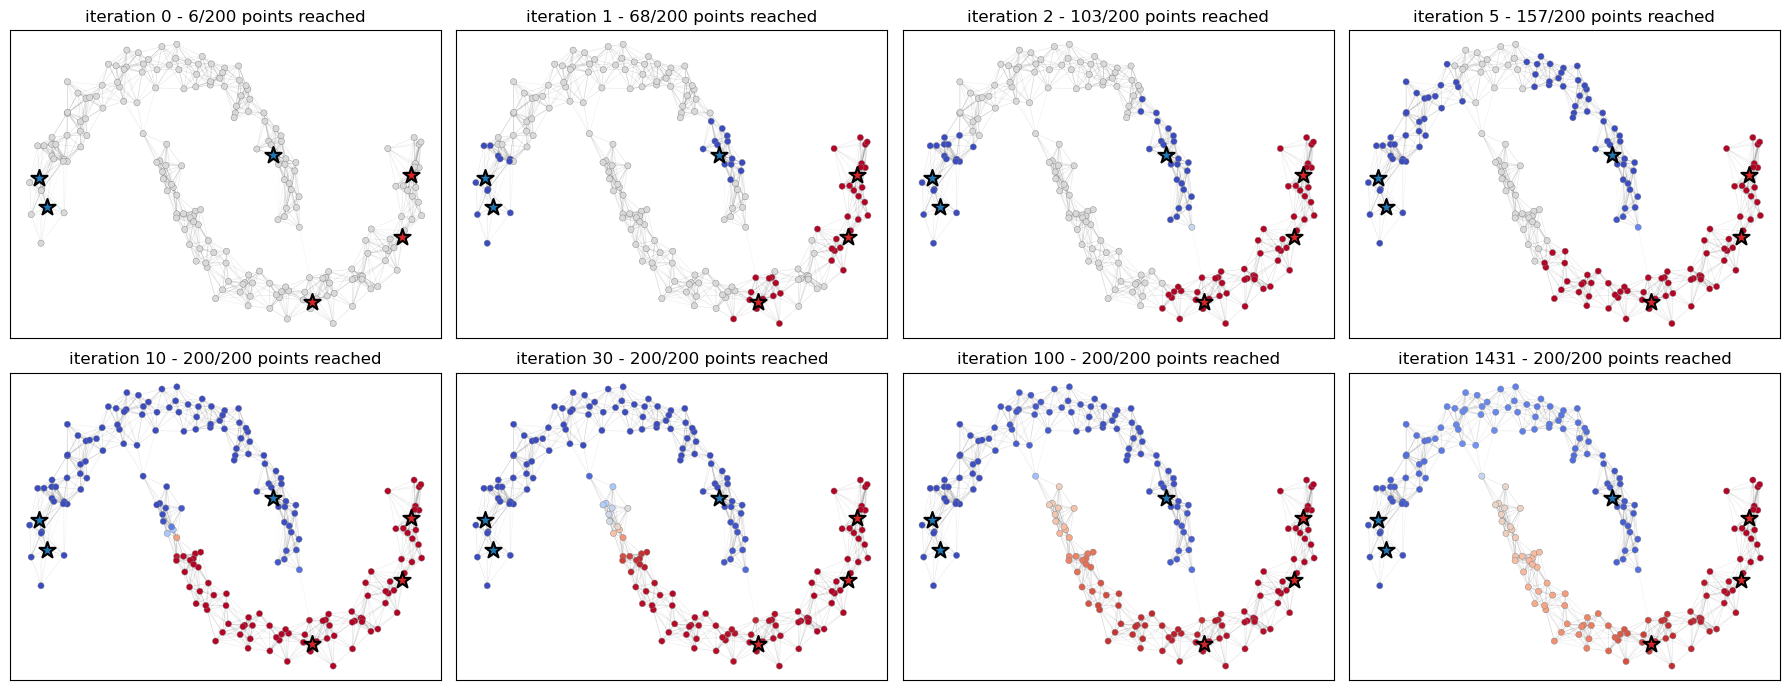

In [10]:
last_iteration = len(history) - 1
snapshots = [0, 1, 2, 5, 10, 30, 100, last_iteration]

fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()    # turn the 2x4 grid of axes into a simple list of 8 axes
for number in range(len(snapshots)):
    iteration = snapshots[number]
    plot_state(axes[number], history[iteration], iteration)
plt.tight_layout()
plt.show()

Observe how the labels spread "hop by hop" along the graph: after one iteration, only the direct neighbors of the labeled points are colored, after two iterations the neighbors of the neighbors, and so on. Because there are very few edges between the two moons, each label stays mostly inside its own moon.

### Animation

The same process as an animation (it may take a few seconds to generate). Note that the animation is only visible when running the notebook, not in the GitHub preview.

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=72)

# The labels spread fast at the beginning and slowly at the end, so we show
# every iteration at the beginning, and fewer and fewer iterations later
last_iteration = len(history) - 1
frames = list(range(0, 20)) + list(range(20, 100, 5)) + list(range(100, last_iteration, 50)) + [last_iteration]

def update(iteration):
    # Draw one frame of the animation
    ax.clear()
    plot_state(ax, history[iteration], iteration)

anim = animation.FuncAnimation(fig, update, frames=frames, interval=200)
plt.close(fig)  # avoid displaying an extra static figure
HTML(anim.to_jshtml())

### Convergence

Let us look at how much $F$ changes from one iteration to the next. The change decreases steadily and the algorithm converges, but it needs more than a thousand iterations: the information has to travel along the long, thin moons, and through a few weak edges. This motivates the next section.

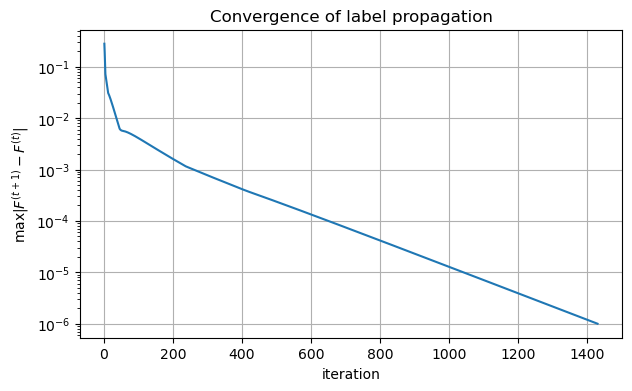

In [12]:
changes = []
for t in range(len(history) - 1):
    change = np.max(np.abs(history[t+1] - history[t]))
    changes.append(change)

plt.figure(figsize=(7, 4))
plt.semilogy(range(1, len(history)), changes)   # logarithmic scale on the y axis
plt.xlabel('iteration')
plt.ylabel(r'$\max |F^{(t+1)} - F^{(t)}|$')
plt.title('Convergence of label propagation')
plt.grid(True)
plt.show()

## 5. The closed-form solution

We do not actually need to iterate: the fixed point of the algorithm can be computed directly. Order the points so that the labeled ones ($L$) come first, and the unlabeled ones ($U$) after. The matrices split into blocks:

$$ T = \begin{pmatrix} T_{LL} & T_{LU} \\ T_{UL} & T_{UU} \end{pmatrix}, \qquad F = \begin{pmatrix} F_L \\ F_U \end{pmatrix}.$$

$F_L = Y_L$ is fixed by clamping, and the update for the unlabeled points is $F_U \leftarrow T_{UL} Y_L + T_{UU} F_U$. At convergence, $F_U$ does not change anymore, so

$$ F_U = T_{UL} Y_L + T_{UU} F_U \quad \Longrightarrow \quad F_U = (I - T_{UU})^{-1}\, T_{UL}\, Y_L .$$

(The matrix $I - T_{UU}$ is invertible as long as every connected component of the graph contains at least one labeled point.)

In [13]:
# Extract the blocks of T: first select the rows of the unlabeled points, then the columns
T_U = T[unlabeled_idx, :]          # rows of the unlabeled points
T_UU = T_U[:, unlabeled_idx]       # ... and columns of the unlabeled points
T_UL = T_U[:, labeled_idx]         # ... and columns of the labeled points
print("Shape of T_UU:", T_UU.shape, "- shape of T_UL:", T_UL.shape)

# Apply the formula F_U = (I - T_UU)^-1 T_UL Y_L
I = np.eye(len(unlabeled_idx))
F_U = np.linalg.inv(I - T_UU) @ T_UL @ Y_L

# Compare with the result of the iterations
F_iterative = history[-1]
difference = np.max(np.abs(F_U - F_iterative[unlabeled_idx]))
print("Max difference between the closed-form and iterative solutions:", difference)

Shape of T_UU: (194, 194) - shape of T_UL: (194, 6)
Max difference between the closed-form and iterative solutions: 0.00016766640350057704


Both solutions agree (the small difference comes from the tolerance `tol` used to stop the iterations).

*Remark*: in practice, it is better (faster and more accurate) to solve the linear system $(I - T_{UU}) F_U = T_{UL} Y_L$ with `np.linalg.solve(I - T_UU, T_UL @ Y_L)` than to compute the inverse of the matrix. Here we used `np.linalg.inv` to stay close to the formula.

For a few hundred points the closed form is perfect. For large datasets, inverting (or solving with) a huge matrix becomes too expensive, and the iterative version is preferred: it only needs matrix-vector products, which are cheap when $W$ is sparse.

## 6. Results

The predicted class is the one with the largest value in each row of $F$. Since we actually know the hidden labels, we can measure the accuracy on the unlabeled points.

Accuracy on the unlabeled points: 0.995
Misclassified points: [73]


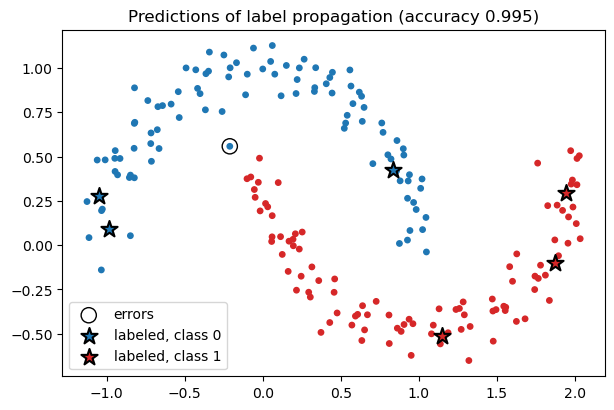

In [14]:
# Predicted class: the column with the largest value in each row of F
y_pred = np.argmax(F_iterative, axis=1)

# Count the correct predictions on the unlabeled points, and remember the errors
n_correct = 0
errors = []
for i in unlabeled_idx:
    if y_pred[i] == y[i]:
        n_correct += 1
    else:
        errors.append(i)
accuracy = n_correct / len(unlabeled_idx)
print(f"Accuracy on the unlabeled points: {accuracy:.3f}")
print("Misclassified points:", np.array(errors))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X[:, 0], X[:, 1], c=labels_to_colors(y_pred), s=15)
ax.scatter(X[errors, 0], X[errors, 1], s=120, facecolors='none', edgecolors='k', label='errors')
plot_labeled_points(ax)
ax.legend(loc='lower left')
ax.set_title(f'Predictions of label propagation (accuracy {accuracy:.3f})')
plt.show()

With only 6 labeled points out of 200, label propagation recovers the two moons almost perfectly!

## 7. Label propagation in scikit-learn

Scikit-learn provides `LabelPropagation` in the module `sklearn.semi_supervised`. It follows the usual `fit`/`predict` interface, and unlabeled points are marked with the label `-1`, exactly like our `y_observed`. With `kernel='knn'`, the graph is a $k$-nearest-neighbor graph with binary weights (1 if connected, 0 otherwise), so the result can differ slightly from our weighted graph.

In [15]:
from sklearn.semi_supervised import LabelPropagation

model = LabelPropagation(kernel='knn', n_neighbors=k, max_iter=5000)
model.fit(X, y_observed)          # unlabeled points have the label -1 in y_observed
y_pred_sk = model.transduction_   # labels inferred for all the training points

accuracy_sk = np.mean(y_pred_sk[unlabeled_idx] == y[unlabeled_idx])
agreement = np.mean(y_pred_sk == y_pred)
print(f"scikit-learn accuracy on the unlabeled points: {accuracy_sk:.3f}")
print(f"Agreement with our implementation: {agreement:.3f}")

scikit-learn accuracy on the unlabeled points: 1.000
Agreement with our implementation: 0.995


Once fitted, the model can also predict the label of new points with `model.predict(X_new)`, and `model.label_distributions_` gives the normalized rows of $F$.

## 8. Exercises

1. **Number of labels.** Run the notebook with only 1 labeled point per class, then with 10 per class. How do the accuracy and the number of iterations change? Does the position of the labeled points matter?
2. **Graph parameters.** Change $k$ (try 3, 5, 30) and $\sigma$ (try 0.05, 1). Plot the graph each time. What happens when $k$ is too large? And when it is too small? *Hint*: use `scipy.sparse.csgraph.connected_components(W)` to count the connected components of the graph. What happens to a component that contains no labeled point?
3. **Supervised baseline.** Train a classifier (e.g. `KNeighborsClassifier(n_neighbors=1)` or `SVC`) using **only** the 6 labeled points, and compute its accuracy on the unlabeled points. Compare with label propagation and explain the difference.
4. **When does it fail?** Increase the `noise` parameter of `make_moons` (0.15, 0.25, ...). At which point does label propagation stop working well, and why? Look at the graph.
5. **Noisy labels.** Give a wrong label to one of the labeled points. How does label propagation react? Try `LabelSpreading` from `sklearn.semi_supervised` with different values of `alpha`: unlike label propagation, it does not completely clamp the labeled points.